# Usporedba metrika - Decision Tree vs Random Forest vs XGBoost

VIDJETI [metrike.md](metrike.md) - ovdje racunamo **macro F1, confusion matrix, log loss i accuracy**
za sva tri modela na identicnom test setu (isti cache znacajki, isti `train_test_split`,
isti hiperparametri kao u pojedinacnim notebookovima), da ih realno usporedimo jedne s drugima.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, log_loss, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier

## Podaci

In [4]:
CACHE_PATH = '../../data/features_cache/znacajke_cache.pkl'

df = pd.read_pickle(CACHE_PATH)

X = df.drop(columns=['label'])
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

classes = list(le.classes_)  # BIC, CAR, HEAVY, MC - isti redoslijed koristimo za sva tri modela

## Treniranje sva tri modela (isti hiperparametri kao u pojedinacnim notebookovima)

In [ ]:
# Decision Tree - max_depth=10
dt = DecisionTreeClassifier(max_depth=10, class_weight='balanced', random_state=42)
dt.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: dict, list of dict or ""balanced"", default=NoneWeights associated with classes in the form ``{class_label: weight}``.If None, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are co

In [ ]:
# Random Forest 
rf = RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_fe

In [ ]:
# XGBoost s early stoppingom
X_tr2, X_val, y_tr2, y_val = train_test_split(X_train, y_train_enc, test_size=0.2, stratify=y_train_enc, random_state=42)
weights_tr2 = compute_sample_weight('balanced', y_tr2)

xgb = XGBClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='mlogloss',
    early_stopping_rounds=30,
    random_state=42,
    n_jobs=-1,
)
xgb.fit(X_tr2, y_tr2, sample_weight=weights_tr2, eval_set=[(X_val, y_val)], verbose=False)
print(f"Zaustavljeno nakon {xgb.best_iteration} stabala (od maksimalnih 1000 dopustenih)")

Zaustavljeno nakon 407 stabala (od maksimalnih 1000 dopustenih)


## Metrike po modelu

In [ ]:
def izracunaj_metrike(naziv, y_true_str, y_pred_str, y_proba, classes):
    """y_true_str/y_pred_str su string labele (BIC/CAR/HEAVY/MC), stupci y_proba moraju biti
    poredani identicno kao `classes` da log loss racuna vjerojatnost prave klase na pravom mjestu."""
    y_true_enc = pd.Categorical(y_true_str, categories=classes).codes
    return {
        'model': naziv,
        'accuracy': accuracy_score(y_true_str, y_pred_str),
        'macro_f1': f1_score(y_true_str, y_pred_str, average='macro'),
        'log_loss': log_loss(y_true_enc, y_proba, labels=list(range(len(classes)))),
    }


rezultati = []
# predict - accuray i macro_f1, predict_proba za log-loss
# Decision Tree
y_pred_dt = dt.predict(X_test)
y_proba_dt = dt.predict_proba(X_test)[:, [list(dt.classes_).index(c) for c in classes]]
rezultati.append(izracunaj_metrike('Decision Tree', y_test.to_numpy(), y_pred_dt, y_proba_dt, classes))

# Random Forest
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, [list(rf.classes_).index(c) for c in classes]]
rezultati.append(izracunaj_metrike('Random Forest', y_test.to_numpy(), y_pred_rf, y_proba_rf, classes))

# XGBoost - predict vraca encodane labele, predict_proba stupce vec poredane 0..3 (= `classes`)
y_pred_xgb = le.inverse_transform(xgb.predict(X_test))
y_proba_xgb = xgb.predict_proba(X_test)
rezultati.append(izracunaj_metrike('XGBoost', y_test.to_numpy(), y_pred_xgb, y_proba_xgb, classes))

metrike_df = pd.DataFrame(rezultati).set_index('model')
metrike_df.round(4)

,accuracy,macro_f1,log_loss
model,,,
Decision Tree,0.7261,0.4833,2.6639
Random Forest,0.8476,0.6403,0.4303
XGBoost,0.8729,0.6667,0.3579


## Confusion matrix - sva tri modela usporedno

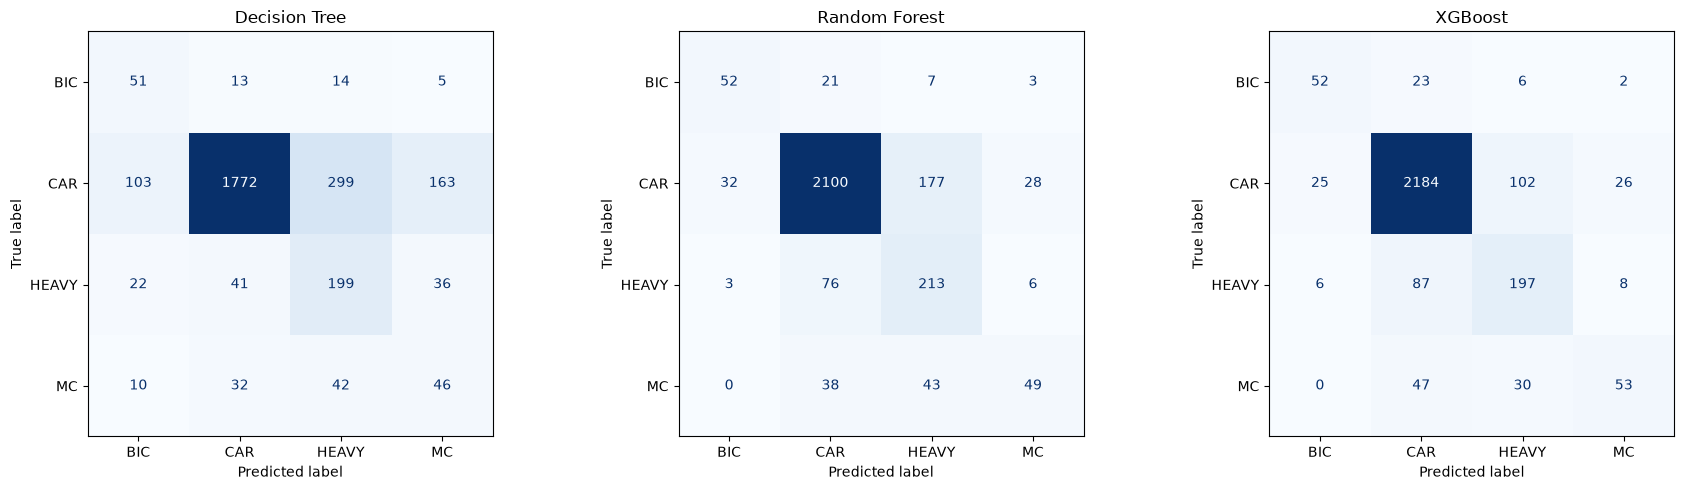

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, naziv, y_pred in zip(
    axes,
    ['Decision Tree', 'Random Forest', 'XGBoost'],
    [y_pred_dt, y_pred_rf, y_pred_xgb],
):
    cm = confusion_matrix(y_test, y_pred, labels=classes)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(naziv)

plt.tight_layout()
plt.show()

## Zaključak

- najbolji macro F1 i najmanji log loss ima XGBoost, a najlosiji je DecisionTree
- najvise se mijesaju CAR i HEAVY klase, pogotovo u DecisionTree-u
- u DT-u se jos mijesaju i CAR i BIC i CAR i MC, ali u RF i XG dobro raspoznaju ostale kalse jedino je HEAVY-CAR relacija malo blurry
- zanimljivo je da DT a i ostali modeli imaju tendanciju obiljezavati dosta toga kao HEAVY
